In [1]:
import sys
import numpy as np
import anndata as ad
import pickle

# Hack to get to src folder (this notebook is in notebooks/shared)
sys.path.insert(0, './toolkit-project/')

import src as scit
import anndata as ad
import polars as pl

# 1. Transfer the UMAP and embedding to the original C&T dataset

In [2]:
scit.set_defaults(figsize= (7,6))

In [3]:
ctad = ad.read_h5ad("../h5ad/emb8_14_comb_filter_250215.h5ad")

### Mildly filtered CT dataset, no UMAP, no leiden

In [3]:
ctad_e = ad.read_h5ad("../h5ad/emb8_10rep1_250215.h5ad")
ctad_l = ad.read_h5ad("../h5ad/emb14_16rep1_250215.h5ad")
ctad = ad.concat([ctad_e, ctad_l])

### Strictly filtered UMAP, MS UMAP and leiden

In [4]:
ctad1 = ad.read_h5ad("../h5ad/emb8_14_comb_filter_250215.h5ad")

### Dataset, integrated with ATAC, based on strict filtering, no matrix, good integrated UMAP and leiden

In [5]:
ctad2 = ad.read_h5ad("../h5ad/ctag_integ_labeled_250218.h5ad")

In [6]:
common_obs_names = ctad2.obs_names
ctad = ctad[ctad.obs_names.isin(common_obs_names)]
all(ctad.obs.index == ctad2.obs.index)

True

In [7]:
print([ctad.shape, ctad1.shape, ctad2.shape])

[(27645, 24130), (27645, 22622), (27645, 0)]


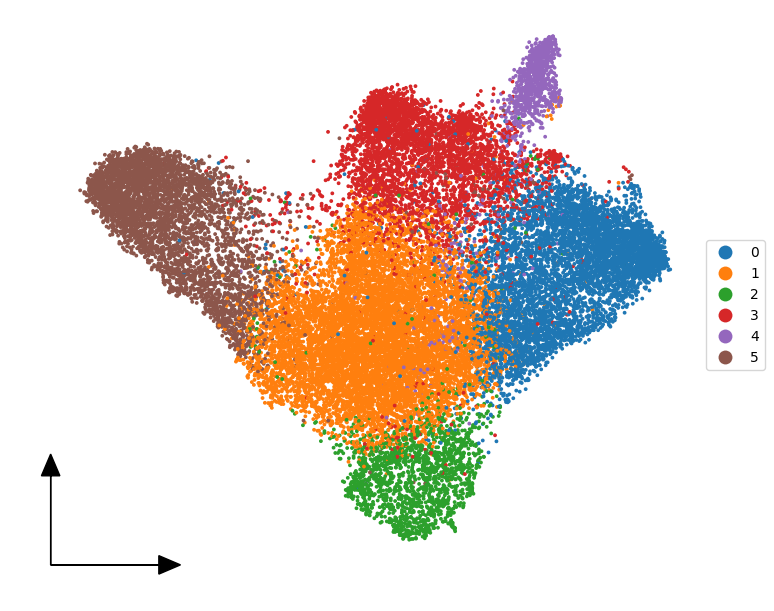

In [8]:
scit.pl.embedding2d(ctad1, "X_umap", 'leiden')

Rename the UMAP from the multispectral embedding

In [9]:
ctad.obsm['X_umap_ms'] = ctad1.obsm['X_umap'].copy()
ctad.obs['leiden_ms'] = ctad1.obs['leiden'].copy()
del ctad.obsm['X_umap']
del ctad.obs['leiden']

/tmp/54259025/ipykernel_1681859/1942242092.py:1: ImplicitModificationWarning: Setting element `.obsm['X_umap_ms']` of view, initializing view as actual.
  ctad.obsm['X_umap_ms'] = ctad1.obsm['X_umap'].copy()


Transfer the data from the integrated dataset

In [10]:
# obsm
ctad.obsm['X_glue'] = ctad2.obsm['X_glue'].copy()
ctad.obsm['X_umap'] = ctad2.obsm['X_umap'].copy()
# obs
ctad.obs['label'] = ctad2.obs['ATAC_label'].copy()
ctad.obs['leiden_glue'] = ctad2.obs['leiden_fix'].copy()

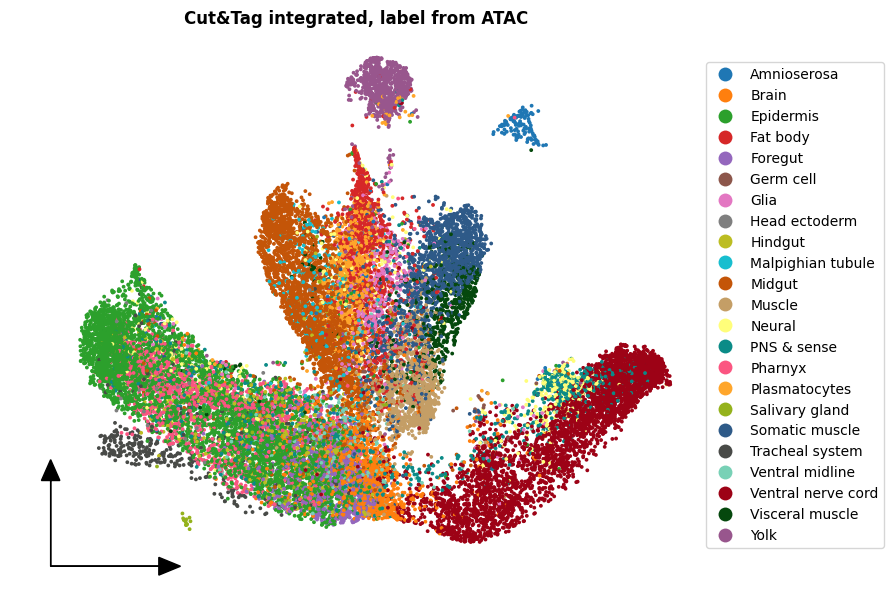

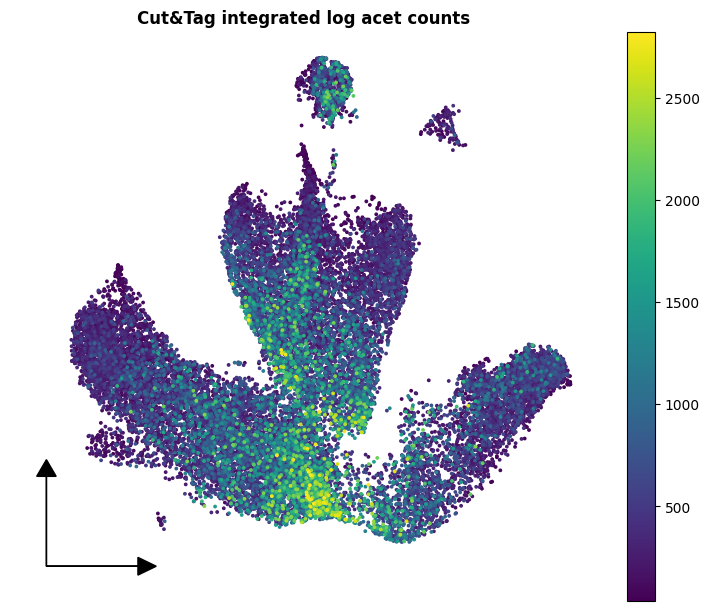

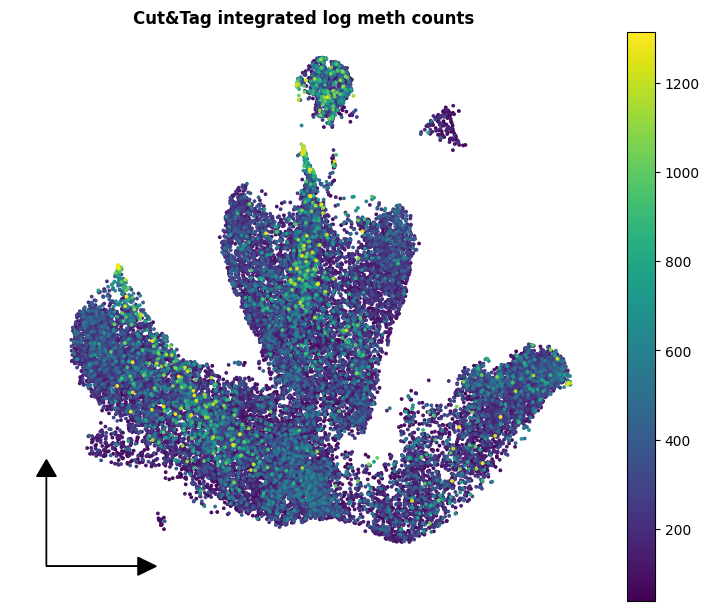

In [11]:
# Plots
scit.pl.embedding2d(ctad, "X_umap", 'label', title = 'Cut&Tag integrated, label from ATAC')
scit.pl.embedding2d(ctad, "X_umap", 'acet_total_counts', title = 'Cut&Tag integrated log acet counts')
scit.pl.embedding2d(ctad, "X_umap", 'meth_total_counts', title = 'Cut&Tag integrated log meth counts')

In [22]:
ctad

AnnData object with n_obs × n_vars = 27645 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue'
    uns: 'colors_dict'
    obsm: 'X_acetylation', 'X_methylation', 'X_multi_spectral', 'X_umap_ms', 'X_glue', 'X_umap'
    layers: 'acet', 'meth'

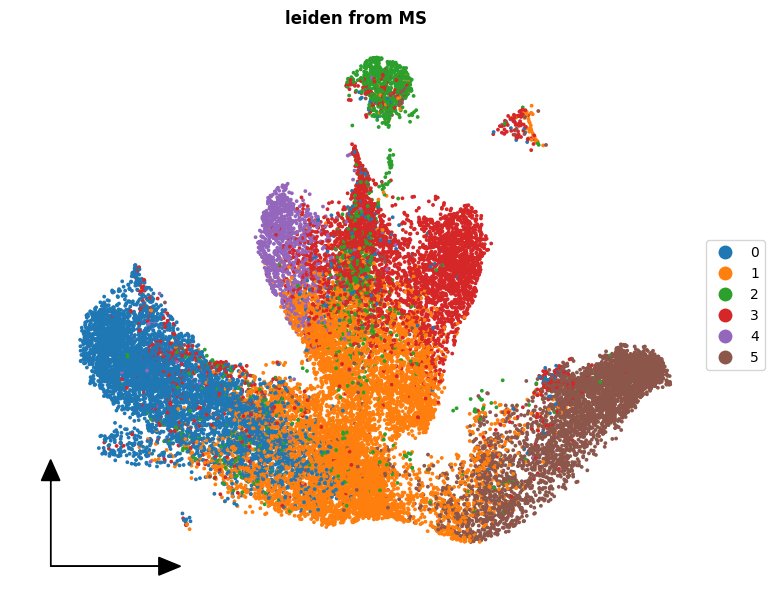

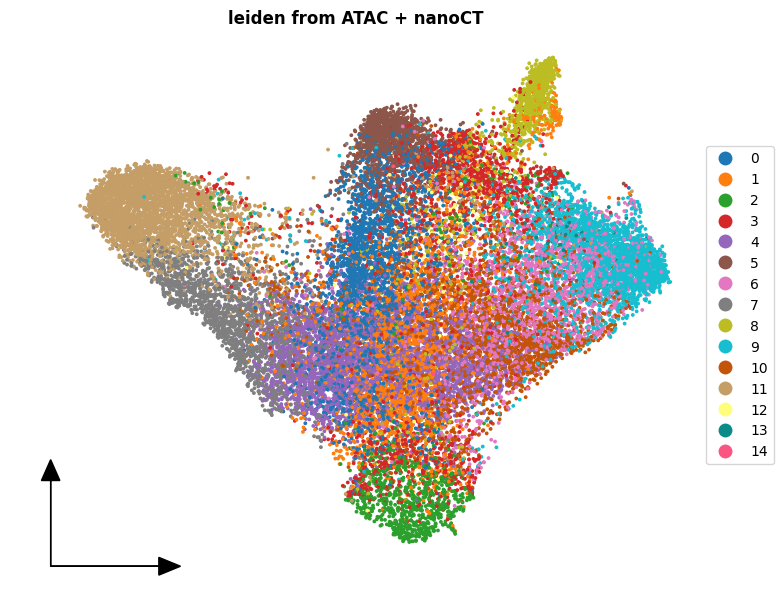

In [13]:
scit.pl.embedding2d(ctad, "X_umap", 'leiden_ms', title = "leiden from MS")
scit.pl.embedding2d(ctad, "X_umap_ms", 'leiden_glue', title = "leiden from ATAC + nanoCT")

In [14]:
scit.tl.add_metadata(ctad, var_loc_metadata = False)

In [15]:
ctad

AnnData object with n_obs × n_vars = 27645 × 24130
    obs: 'batch', 'meth_total_counts', 'meth_log_total_counts', 'acet_total_counts', 'acet_log_total_counts', 'exclude', 'timep', 'leiden_ms', 'label', 'leiden_glue'
    var: 'acet_total_counts', 'acet_log_total_counts', 'meth_total_counts', 'meth_log_total_counts'
    uns: 'colors_dict'
    obsm: 'X_acetylation', 'X_methylation', 'X_multi_spectral', 'X_umap_ms', 'X_glue', 'X_umap'
    layers: 'acet', 'meth'

In [16]:
ctad.write_h5ad("../h5ad/ctag_integ_labeled_FULL-250218.h5ad")

# 2. Void state

In [17]:
# Make layer configurations
lc_acet = scit.tl.make_layer_config("acet", log_transform=True, normalize_with_obs_counts=True)
lc_meth = scit.tl.make_layer_config("meth", log_transform=True, normalize_with_obs_counts=True)

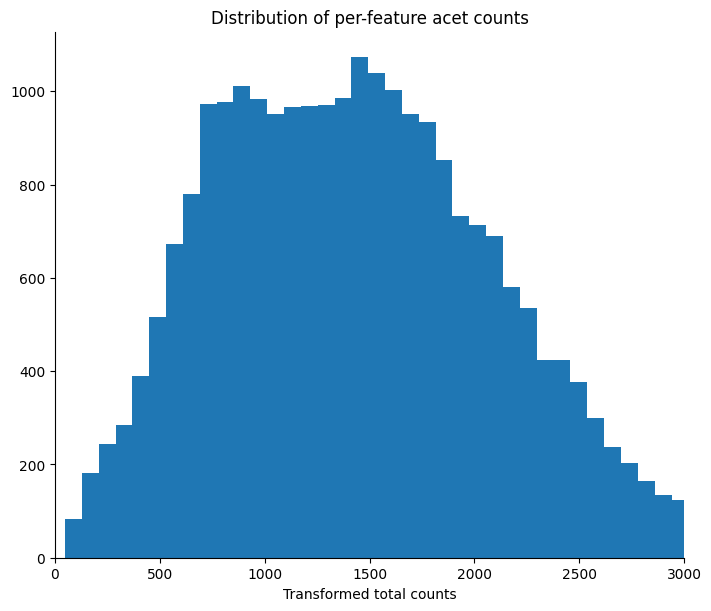

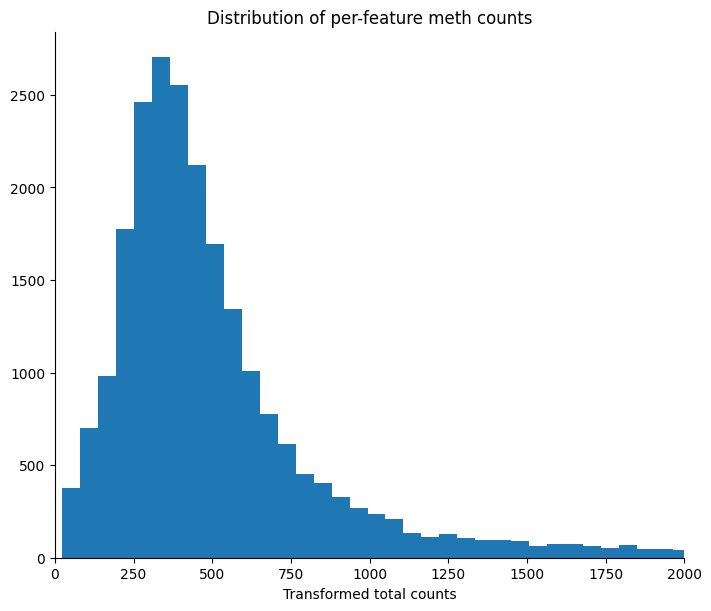

In [18]:
# Visualize bin total counts

scit.pl.layer_config_histogram(ctad, lc_acet, bins=100, xminmax=(0,3000), total_counts=True)
scit.pl.layer_config_histogram(ctad, lc_meth, bins=300, xminmax=(0,2000), total_counts=True)

In [19]:
# Pick thresholds for removing low-quality reads (they will be binarized)
# Thresholds are after all transformations

lc_acet = scit.tl.make_layer_config(
    'acet',
    idf_transform=True,
    log_transform=True,
    normalize_with_l2_norm=True,
    feature_active_threshold=5.6
)
lc_meth = scit.tl.make_layer_config(
    'meth',
    idf_transform=True,
    log_transform=True,
    normalize_with_l2_norm=True,
    feature_active_threshold=6.0
)

Info: Passing entries (> 5.6): 9212520 (72.67%)


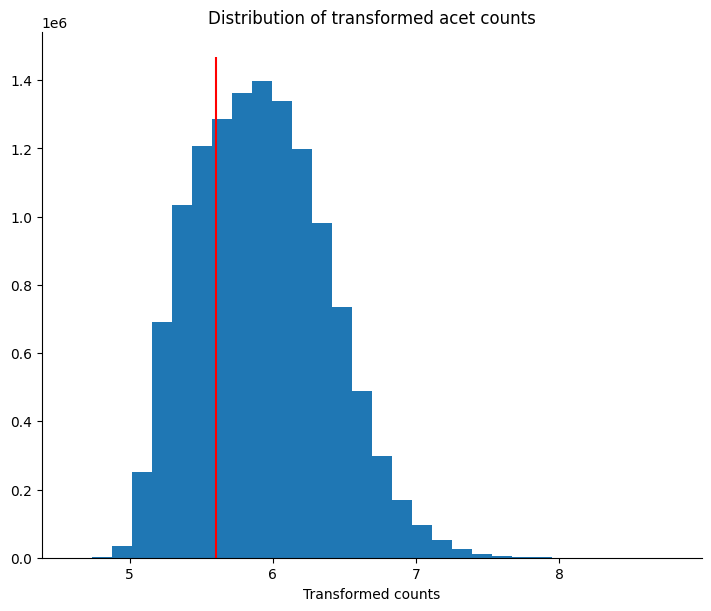

Info: Passing entries (> 6.0): 3900267 (72.40%)


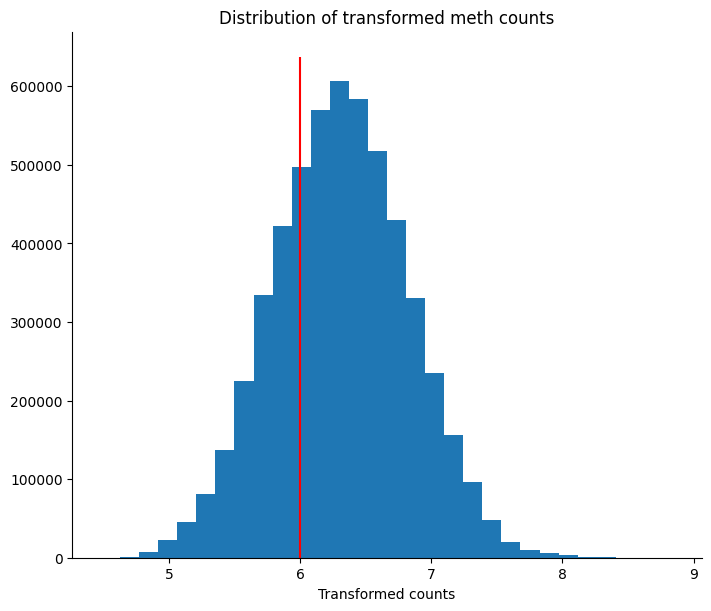

In [20]:
# Histograms for read data (not per-feature, but all recorded data from the sparse matrix)

scit.pl.layer_config_histogram(ctad, lc_acet)
scit.pl.layer_config_histogram(ctad, lc_meth)

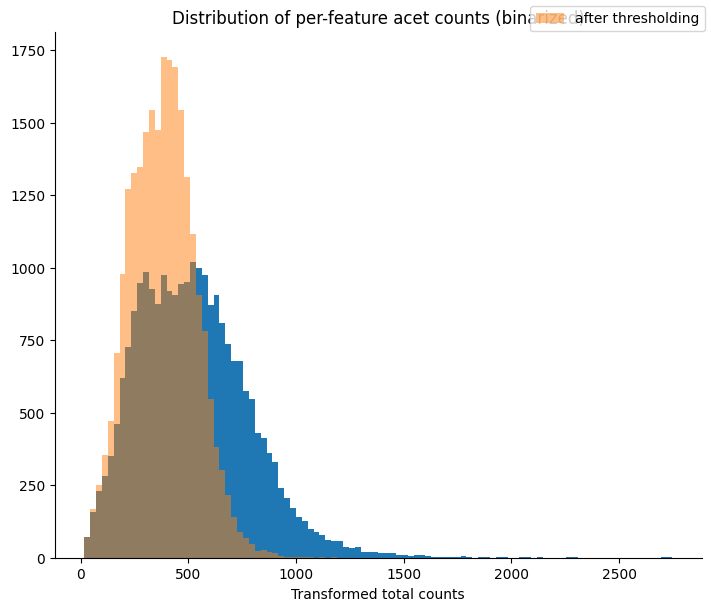

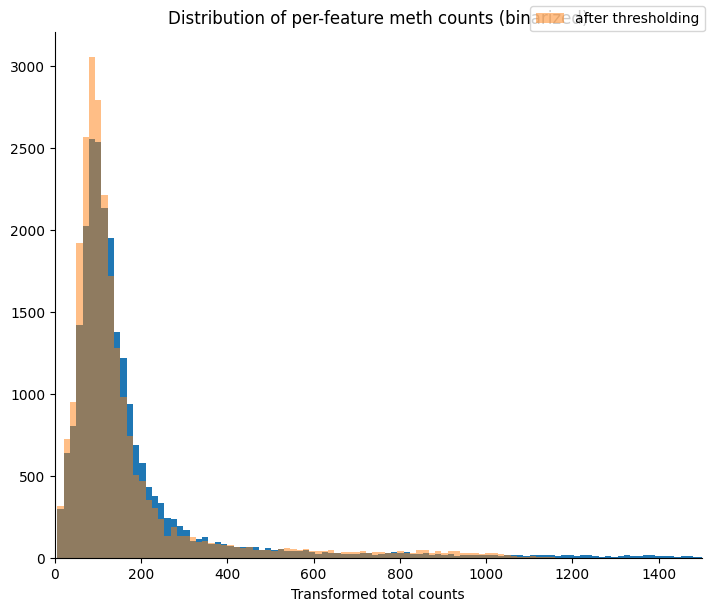

In [21]:
# Visualize per-feature total count binarized counts, with and without threshold to see how thresholding affects the data

scit.pl.layer_config_histogram(ctad, lc_acet, total_counts=True, after_binarization=True, bins=100)
scit.pl.layer_config_histogram(ctad, lc_meth, total_counts=True, after_binarization=True, bins=300, xminmax=(0, 1500))


In [22]:
# Exclude genes below potential threshold
# 1% of cells needs to have signal

potential_th = int(ctad.shape[0] * 0.01)
print(potential_th)

276


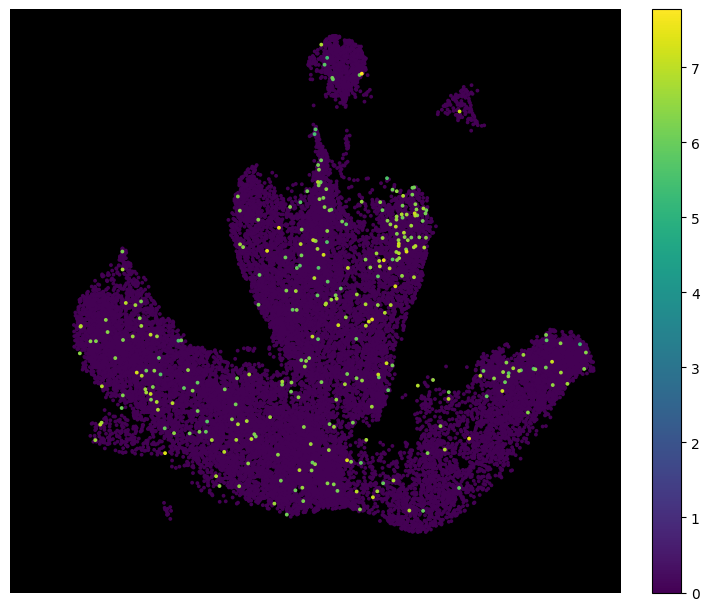

In [23]:
scit.tl.layer_pick_features(ctad, lc_meth, after_binarization = True,
                            filter_max = potential_th, filter_min = potential_th - 20)

# Pick a random bin to check if it really should be excluded,
# if not, adjust the potential threshold above to be more strict/lenient
no_pass = np.arange(lc_meth.get_shape(ctad)[1])[lc_meth.cached_mask]
scit.tl.layer_pick_features(ctad, lc_meth, no_pass[2])

# Check if these are the features you want to exclude
scit.tl.copy_to_obs(ctad, lc_meth)
scit.pl.embedding2d(ctad, 'X_umap', 'copied_data', black_background=True)

In [24]:
ctad.layers['meth_binary'] = lc_meth.transform(ctad, binarize=True)
ctad.layers['acet_binary'] = lc_acet.transform(ctad, binarize=True)

In [25]:
# ilb = integrated, labeled, binarized
ctad.write_h5ad("../h5ad/ctag_ilb-250218.h5ad")